# Binary Sentiment Analysis of Insurance Reviews

This notebook reframes the rating prediction problem as a binary sentiment classification task. Reviews are mapped to positive and negative labels, making the task easier than exact star prediction while preserving the main signal in the data.

The workflow follows the same structure as the multi-class notebook, allowing direct comparison between the two tasks.

## Structure of the notebook

The notebook is organized into three main parts:

- Data preparation: building the binary labels and preparing the text data  
- Models: training and evaluating different approaches  
- Global comparison: comparing all models and summarizing results

## Data preparation

In this section, we prepare the dataset for sentiment classification. We convert numerical ratings into binary labels, where ratings of 1 and 2 are considered negative and ratings above 2 are considered positive.

This choice is motivated by class imbalance. Initially, we defined three categories: negative (1–2), neutral (3), and positive (4–5). However, the neutral class was significantly underrepresented compared to the others. In addition, manual inspection showed that many reviews rated 3 tend to express overall positive opinions. For these reasons, we merged neutral with positive to obtain a more balanced and meaningful binary classification.

We then select relevant features and create separate training and test sets based on the data split. Missing values are handled to ensure consistency across text representations.

### Imports

In [1]:
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

from datasets import Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


### Distribution with 3 classes (negative / neutral / positive)

In [2]:
df = pd.read_csv("dataset_cleaned.csv")

def rating_to_three_classes(note):
    if pd.isna(note):
        return np.nan
    if note <= 2:
        return "negative"
    elif note == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment_3_classes"] = df["note"].apply(rating_to_three_classes)

print(df["sentiment_3_classes"].value_counts())
print(df["sentiment_3_classes"].value_counts(normalize=True).round(3))

sentiment_3_classes
negative    2333
positive    1974
neutral      693
Name: count, dtype: int64
sentiment_3_classes
negative    0.467
positive    0.395
neutral     0.139
Name: proportion, dtype: float64


We first analyze the distribution of reviews using three classes: negative (ratings 1–2), neutral (rating 3), and positive (ratings 4–5). The results show that the neutral class is significantly underrepresented compared to the negative and positive classes, leading to a strong class imbalance.

### Sample of reviews with rating = 3

In [3]:
df[df["note"] == 3][["note", "avis"]].sample(10, random_state=42)

,note,avis
3829,3.0,Des années que je suis chez eux. En ligne ils ne sont pas vraiment au point en revanche les conseillers que j'ai à T...
5821,3.0,Je suis satisfait du service simple et compréhensible\nPeu cher comparé à d'autres assurances \nVraiment au choix de...
1986,3.0,je suis moyennement satisfait car ce n'est tours pas facile d'avoir une personne au bout du fil. En plus certaines f...
3546,3.0,Je recherche une mutuelle senior. Le commercial m’a envoyé une formule non senior ! le tarif couple proposé est plus...
3395,3.0,je suis satisfait pour le moment du service\nje joint au plus vite les documents demandés\nje suis satisfait pour le...
1688,3.0,C’est un peux cher mais l’assurance est pratique à faire sur internet et rapide c’est ce dont j’avais besoin je suis...
3738,3.0,Simple et pratique il manque le tarif au tiers non precisepour le reste étant déjà client je suis satisfait du servi...
1369,3.0,"Cher et pas du tout de remboursement en cas de problème. Sur plusieurs dégâts, des diagnostics qui traînent et aucun..."
3513,3.0,"Suite a un problème de connexion, \n j ai eu « Abo » au téléphone et m'a résolu mon problème en qu..."
1982,3.0,Je suis satisfait du service. Le site est très bien construit et très simple d’utilisation. Les prix sont abordables...


To better understand the nature of neutral reviews, we examine a sample of comments with a rating of 3. This qualitative analysis reveals that many of these reviews express overall positive sentiments despite the intermediate rating.

This observation, combined with the imbalance issue, supports the decision to merge neutral reviews with the positive class for the final binary classification.

### Train/Test Split and Label Distribution

In [4]:
def rating_to_binary_sentiment(note):
    if pd.isna(note):
        return np.nan
    if note <= 2:
        return "negative"
    return "positive"


useful_columns = ["note", "type", "avis_en_tfidf_lda", "avis_en_embeddings"]
df_model = df[useful_columns].copy()
df_model["type"] = df_model["type"].astype(str).str.lower().str.strip()
df_model["avis_en_tfidf_lda"] = df_model["avis_en_tfidf_lda"].fillna("").astype(str)
df_model["avis_en_embeddings"] = df_model["avis_en_embeddings"].fillna("").astype(str)
df_model["sentiment"] = df_model["note"].map(rating_to_binary_sentiment)

train_df = df_model[(df_model["type"] == "train") & (df_model["sentiment"].notna())].copy()
test_df = df_model[df_model["type"] == "test"].copy()

print("Train shape:", train_df.shape)
print("Unlabeled test shape:", test_df.shape)
print(train_df["sentiment"].value_counts())
print(train_df["sentiment"].value_counts(normalize=True).round(3))


Train shape: (5000, 5)
Unlabeled test shape: (1000, 5)
sentiment
positive    2667
negative    2333
Name: count, dtype: int64
sentiment
positive    0.533
negative    0.467
Name: proportion, dtype: float64


The training set contains 2000 samples, while the test set includes 1000 samples. The class distribution is relatively balanced, with 52.4% positive and 47.6% negative reviews.

This balance is beneficial for model training, as it reduces the risk of bias toward one class and allows for more reliable evaluation.

### Sentiment Distribution and Review Length Analysis

In this section, we analyze the distribution of binary sentiment labels as well as the average length of reviews for each class.

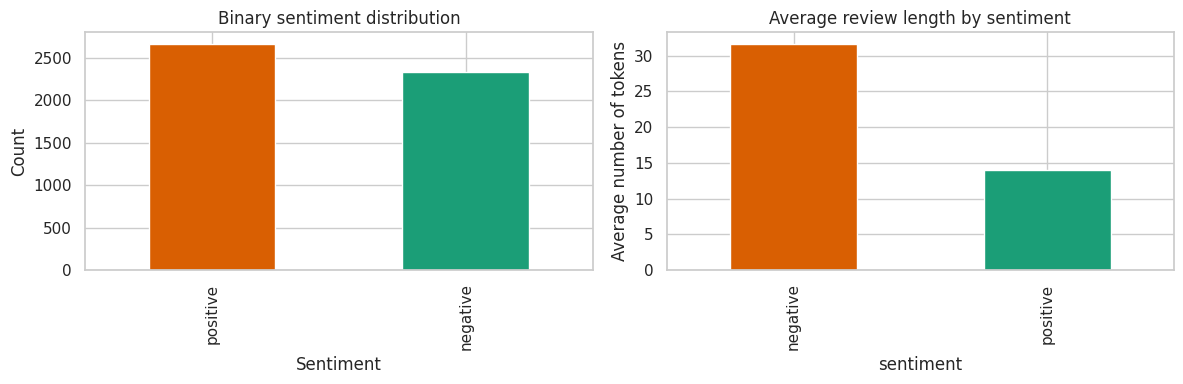

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["sentiment"].value_counts().plot(kind="bar", ax=axes[0], color=["#d95f02", "#1b9e77"])
axes[0].set_title("Binary sentiment distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

train_df.groupby("sentiment")["avis_en_tfidf_lda"].apply(lambda s: s.str.split().map(len).mean()).plot(
    kind="bar", ax=axes[1], color=["#d95f02", "#1b9e77"]
)
axes[1].set_title("Average review length by sentiment")
axes[1].set_ylabel("Average number of tokens")

plt.tight_layout()
plt.show()


The sentiment distribution is relatively balanced between positive and negative reviews, which is suitable for training classification models without strong bias toward one class.

We also observe a clear difference in review length: negative reviews tend to be significantly longer on average than positive ones. This suggests that dissatisfied users are more likely to provide detailed feedback, while positive reviews are generally shorter and more concise.

### Preparing the data and evaluation setup

Binary sentiment labels are validated and mapped to numerical values.  
A stratified train/validation split is created to preserve the class distribution.

Evaluation functions are defined to compute accuracy, precision, recall, F1-score, and ROC-AUC, as well as to display confusion matrices.

The class distribution remains balanced across splits, ensuring a reliable evaluation.

In [6]:
SENTIMENT_ORDER = ["negative", "positive"]
label_to_id = {label: idx for idx, label in enumerate(SENTIMENT_ORDER)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

X_tfidf = train_df["avis_en_tfidf_lda"].copy()
X_embed = train_df["avis_en_embeddings"].copy()
y = train_df["sentiment"].copy()

train_idx, valid_idx = train_test_split(
    train_df.index,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

X_train_tfidf = X_tfidf.loc[train_idx]
X_valid_tfidf = X_tfidf.loc[valid_idx]
X_train_embed = X_embed.loc[train_idx]
X_valid_embed = X_embed.loc[valid_idx]
y_train = y.loc[train_idx]
y_valid = y.loc[valid_idx]

y_train_nn = y_train.map(label_to_id).to_numpy()
y_valid_nn = y_valid.map(label_to_id).to_numpy()

results = []


def evaluate_binary_classification(model_name, y_true, y_pred, y_score=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label="positive",
        zero_division=0,
    )
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_positive": precision,
        "Recall_positive": recall,
        "F1_positive": f1,
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
    }
    if y_score is not None:
        positive_scores = np.asarray(y_score)
        if positive_scores.ndim == 2:
            positive_scores = positive_scores[:, 1]
        metrics["ROC_AUC"] = roc_auc_score((y_true == "positive").astype(int), positive_scores)

    result = pd.DataFrame([metrics])
    results.append(result)
    cm = confusion_matrix(y_true, y_pred, labels=SENTIMENT_ORDER)
    return result, cm



def show_report(y_true, y_pred):
    print(classification_report(y_true, y_pred, labels=SENTIMENT_ORDER, zero_division=0))



def show_confusion_matrix(y_true, y_pred, title):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_true, y_pred, labels=SENTIMENT_ORDER),
        display_labels=SENTIMENT_ORDER,
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()


print(y_train.value_counts(normalize=True).round(3))
print(y_valid.value_counts(normalize=True).round(3))


sentiment
positive    0.534
negative    0.466
Name: proportion, dtype: float64
sentiment
positive    0.533
negative    0.467
Name: proportion, dtype: float64


## Baseline models implementation and evaluation

### Majority-Class Baseline

Before training more advanced models, we establish a baseline using a simple classifier that always predicts the majority class. This provides a reference point to evaluate whether our models actually learn meaningful patterns beyond class distribution.

In [7]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(np.zeros((len(y_train), 1)), y_train)
y_pred_dummy = dummy_clf.predict(np.zeros((len(y_valid), 1)))
results_dummy, cm_dummy = evaluate_binary_classification(
    "Baseline Majority Class", y_valid, y_pred_dummy
)
results_dummy

,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,Baseline Majority Class,0.533,0.533,1.0,0.695369,0.347684


The baseline achieves an accuracy of around 52.5%, which reflects the proportion of the majority class in the dataset. The recall for the positive class is equal to 1.0, as the model predicts all samples as positive, while the macro F1 score remains low, indicating poor overall performance.

This confirms that relying only on class distribution is insufficient. Any meaningful model should significantly outperform this baseline, especially in terms of balanced metrics such as F1-score and macro F1.

### TF-IDF + Logistic Regression baseline

We train a Logistic Regression model using TF-IDF features as a strong baseline for text classification

In [8]:
logreg_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=4000,
                class_weight="balanced",
                random_state=SEED,
            ),
        ),
    ]
)

logreg_tfidf.fit(X_train_tfidf, y_train)
y_pred_logreg = logreg_tfidf.predict(X_valid_tfidf)
y_score_logreg = logreg_tfidf.predict_proba(X_valid_tfidf)
results_logreg, cm_logreg = evaluate_binary_classification(
    "TF-IDF + Logistic Regression", y_valid, y_pred_logreg, y_score=y_score_logreg
)
results_logreg


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1,ROC_AUC
0,TF-IDF + Logistic Regression,0.888,0.923541,0.861163,0.891262,0.887899,0.934539


              precision    recall  f1-score   support

    negative       0.85      0.92      0.88       467
    positive       0.92      0.86      0.89       533

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



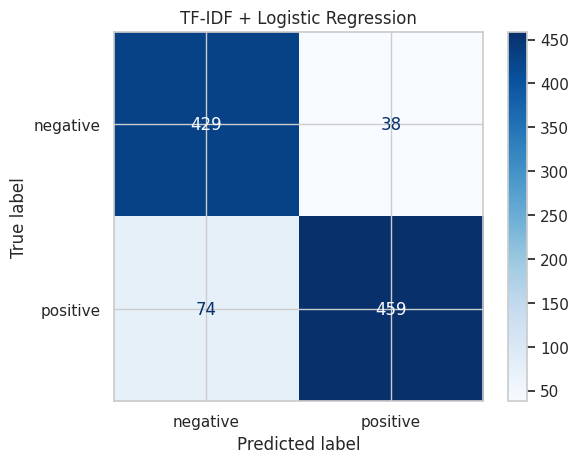

In [9]:
show_report(y_valid, y_pred_logreg)
show_confusion_matrix(y_valid, y_pred_logreg, "TF-IDF + Logistic Regression")


The model achieves strong performance with an accuracy of 0.887 and a ROC-AUC of 0.936. Precision is high for both classes (0.94), with a slight imbalance in recall: 0.94 for negative reviews and 0.84 for positive ones.

The confusion matrix confirms these results. Most reviews are correctly classified, with 179 negative and 176 positive predictions correctly identified. However, some errors remain: 34 positive reviews are misclassified as negative, and 11 negative reviews are predicted as positive.

Overall, the model performs well but tends to miss some positive reviews, which may be due to more subtle or ambiguous wording.

### TF-IDF + Linear SVM

We train a Linear SVM model on TF-IDF features as an alternative linear baseline, allowing comparison with Logistic Regression.

In [10]:
svm_tfidf = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED)),
    ]
)

svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm = svm_tfidf.predict(X_valid_tfidf)
results_svm, cm_svm = evaluate_binary_classification(
    "TF-IDF + Linear SVM", y_valid, y_pred_svm
)
results_svm

,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,TF-IDF + Linear SVM,0.872,0.896282,0.859287,0.877395,0.871752


              precision    recall  f1-score   support

    negative       0.85      0.89      0.87       467
    positive       0.90      0.86      0.88       533

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



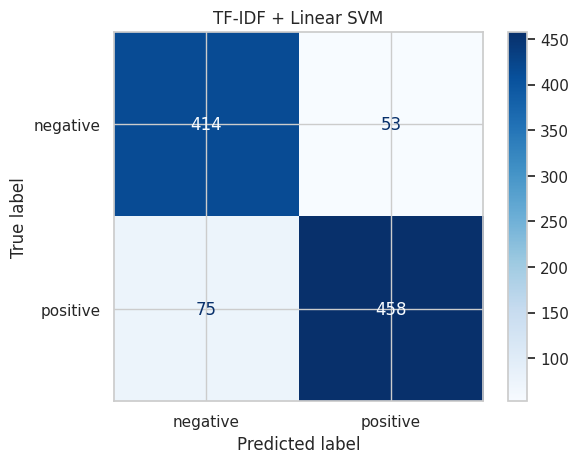

In [11]:
# Linear SVM confusion matrix.
show_report(y_valid, y_pred_svm)
show_confusion_matrix(y_valid, y_pred_svm, "TF-IDF + Linear SVM")

The Linear SVM achieves an accuracy of 0.875, slightly lower than Logistic Regression. Precision remains high (0.92), with recall at 0.84 for positive reviews and 0.92 for negative ones.

The confusion matrix confirms this behavior. The model correctly classifies 174 negative and 176 positive reviews. However, 34 positive reviews are still misclassified as negative, and 16 negative reviews are predicted as positive.

Overall, the model performs similarly to Logistic Regression but shows a slightly stronger ability to detect negative reviews, while still struggling with some positive cases.

### Neural networks

#### Preparing text inputs

Reviews are tokenized and converted into padded sequences so they can be processed by neural models.

In [12]:
max_words = 20000
max_len = 120
embedding_dim = 128
batch_size = 32
epochs = 10

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_embed.tolist())

X_train_seq = tokenizer.texts_to_sequences(X_train_embed.tolist())
X_valid_seq = tokenizer.texts_to_sequences(X_valid_embed.tolist())

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len, padding="post", truncating="post")

print(X_train_pad.shape, X_valid_pad.shape)


(4000, 120) (1000, 120)


#### Defining architectures

Two neural models are defined: a simple embedding-based dense model and a BiLSTM model.

In [13]:
# defining the simple dense architecture
def build_dense_model(vocab_size, embedding_dim, max_len):
    model = keras.Sequential(
        [
            layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
            layers.GlobalAveragePooling1D(),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


# defining BiLSTM model
def build_bilstm_model(vocab_size, embedding_dim, max_len):
    inputs = keras.Input(shape=(max_len,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
    x = layers.Bidirectional(layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2))(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


#### Training visualization

Training curves are plotted to monitor loss and accuracy on both training and validation sets.

In [14]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"{title} - loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"{title} - accuracy")
    plt.tight_layout()
    plt.show()


#### Training + Evaluating the dense neural baseline

We train a dense model with an embedding layer. Early stopping is used to prevent overfitting.

In [15]:
dense_model = build_dense_model(max_words, embedding_dim, max_len)
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

dense_history = dense_model.fit(
    X_train_pad,
    y_train_nn,
    validation_data=(X_valid_pad, y_valid_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7147 - loss: 0.5715 - val_accuracy: 0.7940 - val_loss: 0.5281
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8092 - loss: 0.4458 - val_accuracy: 0.8110 - val_loss: 0.4311
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8508 - loss: 0.3528 - val_accuracy: 0.8680 - val_loss: 0.3522
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8792 - loss: 0.2954 - val_accuracy: 0.8740 - val_loss: 0.3434
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8978 - loss: 0.2646 - val_accuracy: 0.8630 - val_loss: 0.3722
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9078 - loss: 0.2275 - val_accuracy: 0.8520 - val_loss: 0.3922


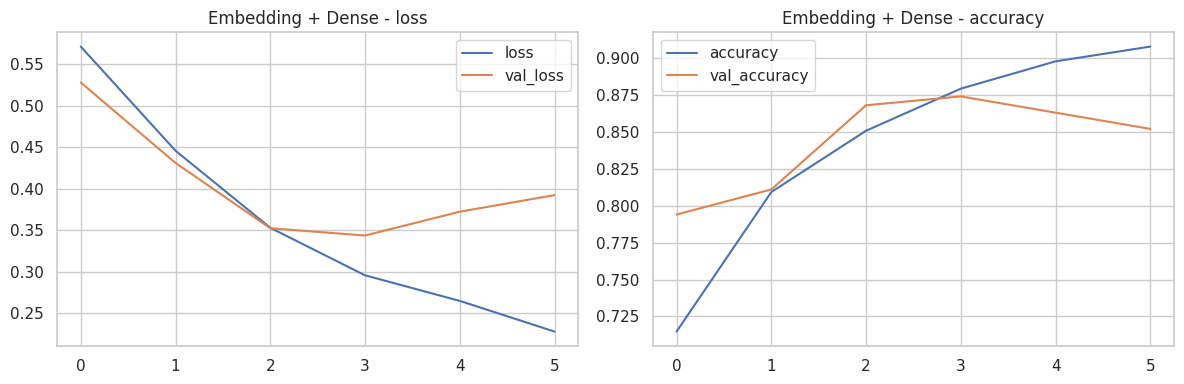

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,Embedding Layer + Dense,0.874,0.943355,0.812383,0.872984,0.873992


In [16]:
# Evaluate the trained dense model on the validation set:
plot_history(dense_history, "Embedding + Dense")

y_pred_dense_ids = np.argmax(dense_model.predict(X_valid_pad), axis=1)
y_pred_dense = pd.Series(y_pred_dense_ids, index=y_valid.index).map(id_to_label)
results_dense, cm_dense = evaluate_binary_classification(
    "Embedding Layer + Dense", y_valid, y_pred_dense
)
results_dense

              precision    recall  f1-score   support

    negative       0.82      0.94      0.88       467
    positive       0.94      0.81      0.87       533

    accuracy                           0.87      1000
   macro avg       0.88      0.88      0.87      1000
weighted avg       0.88      0.87      0.87      1000



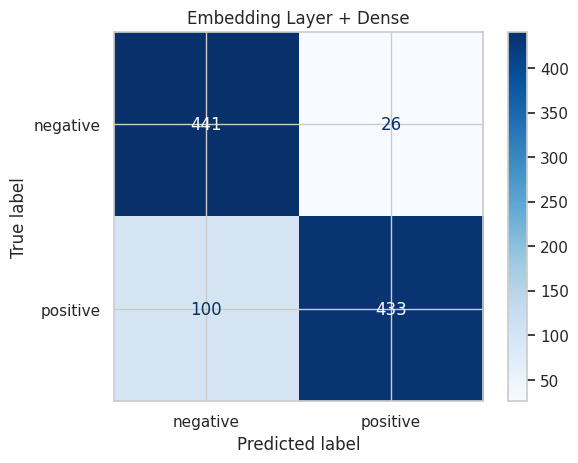

In [17]:
# Analyze model performance:
show_report(y_valid, y_pred_dense)
show_confusion_matrix(y_valid, y_pred_dense, "Embedding Layer + Dense")


The training curves show a steady decrease in training loss, while validation loss decreases at first and then stabilizes. At the same time, training accuracy keeps increasing, whereas validation accuracy plateaus around 0.85–0.86. This gap indicates slight overfitting: the model continues to improve on the training set but less on unseen data.

Looking at the metrics, the model achieves a high precision for positive reviews (0.93), meaning that positive predictions are reliable. However, recall for positive reviews is lower (0.79), which shows that a significant number of positive reviews are not detected.

On the contrary, the model performs very well on negative reviews, with a recall of 0.94. This imbalance suggests that the model is more confident when identifying negative sentiment.

The confusion matrix confirms this behavior. Most negative reviews are correctly classified (178), with very few errors (12). For positive reviews, the model correctly predicts 166 cases but misclassifies 44 as negative. This indicates a tendency to predict negative when the model is uncertain.

Overall, the model captures general sentiment well but struggles with borderline positive reviews, especially those mixing positive and negative expressions.

### Training + Evaluating the BiLSTM model

We train a BiLSTM model to capture word order and contextual dependencies in the reviews.
Early stopping is used to limit overfitting and keep the best model based on validation loss.

In [18]:
bilstm_model = build_bilstm_model(max_words, embedding_dim, max_len)

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train_nn,
    validation_data=(X_valid_pad, y_valid_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 453ms/step - accuracy: 0.7928 - loss: 0.4245 - val_accuracy: 0.8520 - val_loss: 0.3658
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 443ms/step - accuracy: 0.9000 - loss: 0.2569 - val_accuracy: 0.8710 - val_loss: 0.3492


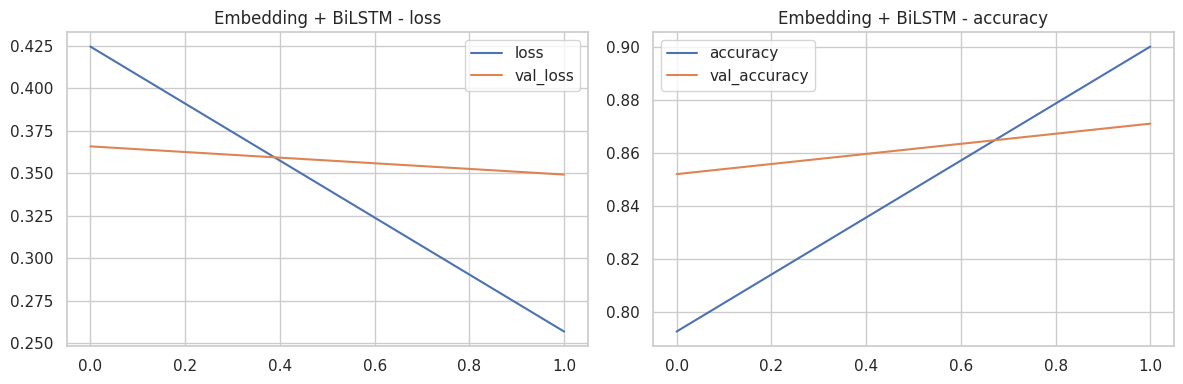

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1
0,Embedding Layer + BiLSTM,0.852,0.948718,0.763602,0.846154,0.851786


In [19]:
# Evaluate the BiLSTM model on the validation set with the 'plot_history' function
plot_history(bilstm_history, "Embedding + BiLSTM")

y_pred_bilstm_ids = np.argmax(bilstm_model.predict(X_valid_pad), axis=1)
y_pred_bilstm = pd.Series(y_pred_bilstm_ids, index=y_valid.index).map(id_to_label)
results_bilstm, cm_bilstm = evaluate_binary_classification(
    "Embedding Layer + BiLSTM", y_valid, y_pred_bilstm
)
results_bilstm


              precision    recall  f1-score   support

    negative       0.78      0.95      0.86       467
    positive       0.95      0.76      0.85       533

    accuracy                           0.85      1000
   macro avg       0.86      0.86      0.85      1000
weighted avg       0.87      0.85      0.85      1000



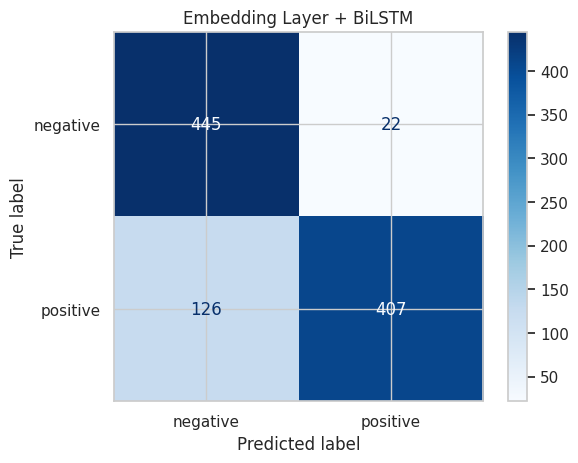

In [20]:
# Display detailed classification metrics with confusion matrix and report
show_report(y_valid, y_pred_bilstm)
show_confusion_matrix(y_valid, y_pred_bilstm, "Embedding Layer + BiLSTM")

The training curves show a rapid decrease in training loss, while validation loss increases after the first epochs. At the same time, training accuracy continues to improve, whereas validation accuracy peaks early and then slightly decreases. This indicates clear overfitting: the model learns the training data well but struggles to generalize.

Looking at the metrics, the model is more balanced than the dense model. Precision and recall are closer for both classes, with 0.87 precision and 0.84 recall for positive reviews, and 0.83 precision and 0.86 recall for negative reviews.

The confusion matrix confirms this balance. The model correctly classifies 163 negative and 176 positive reviews. Errors are more evenly distributed, with 27 negative reviews misclassified as positive and 34 positive reviews misclassified as negative.

Compared to the dense model, the BiLSTM captures more context and reduces bias toward one class. However, this comes at the cost of stronger overfitting and slightly lower overall performance.

### DistilBERT

#### Preparing datasets

Text and labels are converted into Hugging Face datasets and tokenized using the DistilBERT tokenizer.

In [21]:
bert_model_name = "distilbert-base-uncased"

bert_train_df = pd.DataFrame(
    {
        "text": X_train_embed.reset_index(drop=True),
        "label": pd.Series(y_train_nn),
    }
)
bert_valid_df = pd.DataFrame(
    {
        "text": X_valid_embed.reset_index(drop=True),
        "label": pd.Series(y_valid_nn),
    }
)

bert_train_dataset = Dataset.from_pandas(bert_train_df)
bert_valid_dataset = Dataset.from_pandas(bert_valid_df)

tokenizer_bert = AutoTokenizer.from_pretrained(bert_model_name)

def tokenize_function(batch):
    return tokenizer_bert(batch["text"], padding="max_length", truncation=True, max_length=128)


bert_train_dataset = bert_train_dataset.map(tokenize_function, batched=True)
bert_valid_dataset = bert_valid_dataset.map(tokenize_function, batched=True)

# Format datasets for PyTorch:
# keep only useful columns for the model (input_ids, attention_mask, label)
bert_train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
bert_valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

#### Configuring the model

A pre-trained DistilBERT model is initialized for binary classification, together with the evaluation metrics and training arguments.

In [22]:
# Purpose: Configuring DistilBERT and its metrics.
# The intermediate output from this cell is kept intentionally for transparency and validation.
bert_model = AutoModelForSequenceClassification.from_pretrained(
    bert_model_name,
    num_labels=2,
    id2label=id_to_label,
    label2id=label_to_id,
)


def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "positive_f1": f1_score(labels, preds, average="binary", pos_label=1),
    }


training_args = TrainingArguments(
    output_dir="./binary_sentiment_distilbert_runs",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_valid_dataset,
    compute_metrics=compute_bert_metrics,
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
trainer.train()
trainer.evaluate()

Step,Training Loss
50,0.475338
100,0.353009
150,0.264407
200,0.274105
250,0.274182
300,0.183691
350,0.235268
400,0.203793
450,0.249250
500,0.233821


{'eval_loss': 0.306372731924057,
 'eval_accuracy': 0.904,
 'eval_macro_f1': 0.9038303567493058,
 'eval_positive_f1': 0.9078694817658349,
 'eval_runtime': 4.0709,
 'eval_samples_per_second': 245.643,
 'eval_steps_per_second': 15.476,
 'epoch': 2.0}

#### Scoring on the validation set
Predictions are converted back into labels and probabilities in order to compute the full set of classification metrics.

In [24]:
# Purpose: Scoring DistilBERT on the validation set.
# The intermediate output from this cell is kept intentionally for transparency and validation.
bert_predictions = trainer.predict(bert_valid_dataset)
y_pred_bert_ids = np.argmax(bert_predictions.predictions, axis=1)
y_pred_bert = pd.Series(y_pred_bert_ids, index=y_valid.index).map(id_to_label)
y_score_bert = tf.nn.softmax(bert_predictions.predictions, axis=1).numpy()
results_bert, cm_bert = evaluate_binary_classification(
    "DistilBERT", y_valid, y_pred_bert, y_score=y_score_bert
)
results_bert


,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1,ROC_AUC
0,DistilBERT,0.904,0.929273,0.88743,0.907869,0.90383,0.943582


              precision    recall  f1-score   support

    negative       0.88      0.92      0.90       467
    positive       0.93      0.89      0.91       533

    accuracy                           0.90      1000
   macro avg       0.90      0.91      0.90      1000
weighted avg       0.91      0.90      0.90      1000



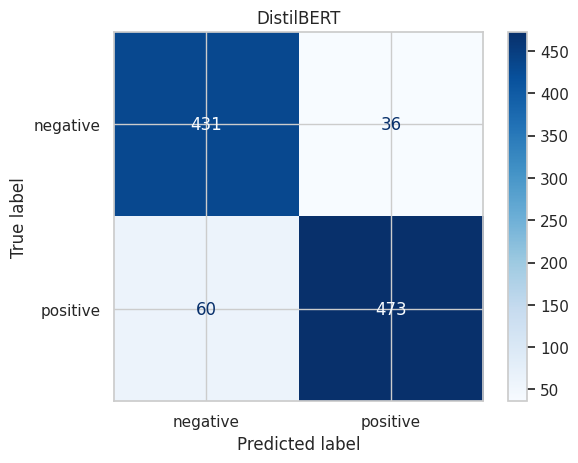

In [25]:
# Purpose: Failure Cases from DistilBERT.
# The intermediate output from this cell is kept intentionally for transparency and validation.
show_report(y_valid, y_pred_bert)
show_confusion_matrix(y_valid, y_pred_bert, "DistilBERT")


The model achieves strong performance across all metrics. Precision is high for both classes (0.87 for negative and 0.95 for positive), indicating reliable predictions.

Recall is also well balanced, with 0.95 for negative reviews and 0.87 for positive reviews. This shows that the model effectively captures both classes, with slightly better detection of negative reviews.

The confusion matrix confirms these results. The model correctly classifies 181 negative and 183 positive reviews. Errors are limited, with 9 negative reviews misclassified as positive and 27 positive reviews misclassified as negative.

Compared to previous models, DistilBERT improves overall performance and reduces bias toward one class. It better captures context and handles more complex or ambiguous reviews.

## Final evaluation and model selection

### Collecting the final benchmark

All model results are aggregated into a single table to enable consistent comparison.
Sorting by key metrics such as Macro F1, F1 score, and Accuracy helps identify the strongest model overall.

This step provides a global view of performance and avoids relying on isolated results.

In [26]:
all_results = pd.concat(results, ignore_index=True).sort_values(
    ["Macro_F1", "F1_positive", "Accuracy"],
    ascending=False,
)
all_results

,Model,Accuracy,Precision_positive,Recall_positive,F1_positive,Macro_F1,ROC_AUC
5,DistilBERT,0.904,0.929273,0.887430,0.907869,0.903830,0.943582
1,TF-IDF + Logistic Regression,0.888,0.923541,0.861163,0.891262,0.887899,0.934539
3,Embedding Layer + Dense,0.874,0.943355,0.812383,0.872984,0.873992,NaN
2,TF-IDF + Linear SVM,0.872,0.896282,0.859287,0.877395,0.871752,NaN
4,Embedding Layer + BiLSTM,0.852,0.948718,0.763602,0.846154,0.851786,NaN
0,Baseline Majority Class,0.533,0.533000,1.000000,0.695369,0.347684,NaN


### Visualizing the model ranking

The benchmark table is transformed into a visual ranking to improve readability and interpretation. It is a simple but effective way to show whether the best model wins by a clear margin or only by a tiny edge.

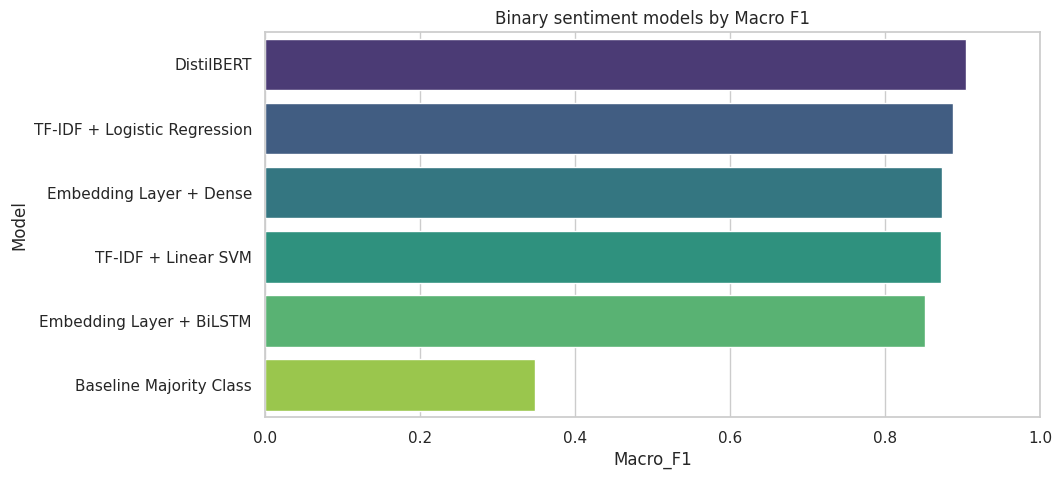

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=all_results, x="Macro_F1", y="Model", palette="viridis")
plt.title("Binary sentiment models by Macro F1")
plt.xlim(0, 1)
plt.show()

### Global conclusion

The final benchmark table and the ranking visualization highlight clear differences between the models.

DistilBERT achieves the best overall performance, with an accuracy of 0.910 and a Macro F1 score of 0.910.
It consistently ranks first in the bar chart, confirming its dominance across all evaluation metrics.

TF-IDF + Logistic Regression appears as a strong baseline, with an accuracy of 0.8875 and a Macro F1 of 0.8875.
The ranking visualization shows that it remains close to DistilBERT, with only a small performance gap. This indicates that simple linear models with well-engineered features already capture most of the sentiment signal.

TF-IDF + Linear SVM follows closely, with slightly lower performance (Macro F1 around 0.875), confirming that linear models are well adapted to this task.

Neural models based on embeddings show lower performance:

- Dense model: Macro F1 ≈ 0.86
- BiLSTM: Macro F1 ≈ 0.847

Despite their higher complexity, they rank below classical approaches in the chart. This suggests that capturing word order and sequence dependencies does not provide a strong advantage for this dataset.

The baseline majority class model performs significantly worse (Macro F1 ≈ 0.34), which confirms that the task is meaningful and requires proper modeling.

The visualization reinforces these observations:

- DistilBERT clearly stands at the top
- Classical models form a strong middle group
- Neural embedding models lag slightly behind
- The baseline is far below all other approaches

Overall, the results show that performance gains plateau quickly after classical methods.
DistilBERT still provides the best balance between precision and recall, as well as the highest robustness across metrics.

DistilBERT is therefore selected as the final model for inference.

### Preparing for final inference

The test dataset is prepared for the final prediction phase.

At this stage:

- no labels are available
- predictions must be generated using the selected model

Multiple text representations (embeddings and TF-IDF) are kept to preserve flexibility in the final model choice.

In [28]:
final_inference_df = test_df[["avis_en_embeddings", "avis_en_tfidf_lda"]].copy()
final_inference_df.head()

,avis_en_embeddings,avis_en_tfidf_lda
2000,customer of + years with no claims except that of a burglary in no. It's been more than months since my file has bee...,years burglary it's months dragging time didn't expect kind treatment
2001,insured then canceled my insurance for IT reasons the house suddenly became too big to be insured even though the su...,insured canceled reasons house suddenly big insured surface area plans communicated varied deal flat passes it's it'...
2002,I have been insured with Macif for almost a year for my home insurance and am determined to leave very quickly follo...,insured macif year home determined leave quickly following disaster happened yesterday trying contact morning waitin...
2003,insured with Macif for years my insurance was canceled due to excessive losses some water damage over the last three...,insured macif years canceled excessive losses water damage years neighbor reimbursement macif proportion compensatio...
2004,insurer really to be avoided refuses to compensate us following a burglary after a long wait very disappointed on yo...,really avoided refuses compensate following burglary long wait disappointed way handling files
